# Is the IC result robust across alternate histories, not just across dates?

`scorer_comparison.ipynb` found every scorer's mean IC statistically
indistinguishable from zero using `evaluation.ic_significance` -- but
that test only uses date-to-date variation WITHIN the one real price
history we have (~40-50 rebalance dates). This notebook uses the
`src2/bootstrap/data_gen.py` engine to generate many
synthetic-but-realistic alternate histories (same dates/tickers,
block-resampled returns/volume) and asks the same question with many
more independent samples: across worlds, not just across dates.

In [5]:
import sys
sys.path.insert(0, '..')

import pandas as pd

from src2 import vector_calc, iteration, evaluation, data_ingest, bootstrap

## 1. Data (same universe as scorer_comparison.ipynb)

In [2]:
# tickers = 'ALGN,AAPL,PANW,AMD,ZS,MDLZ,XEL,VRSN,INSM,ON,WDAY,ENPH,DLTR,ADI,COST,ABNB,CEG,MSFT,GOOGL,CDNS,PYPL,FAST,JD,MTCH,SNPS,LULU,CMCSA,ADBE,ADSK'.split(',')

# tickers=tickers+['SPY','QQQ']

[*********************100%***********************]  31 of 31 completed


In [6]:
tickers=data_ingest.load_total_tickers_nasdaq_2022()

In [ ]:
benchmark_ticker=['SPY','QQQ']

In [20]:
tickers+=benchmark_ticker

In [21]:
broker = data_ingest.DataBroker(tickers=tickers, start_date="2022-01-01", end_date="2026-04-01")
universe_data = broker.fetch_universe_data()

rebalance_dates = iteration.generate_rebalance_dates(universe_data['price'], interval="ME")

[**                     4%                       ]  4 of 114 completed$FI: possibly delisted; no timezone found
[***                    6%                       ]  7 of 114 completed$SPLK: possibly delisted; no timezone found
[******************    37%                       ]  42 of 114 completed$ATVI: possibly delisted; no timezone found
[******************    38%                       ]  43 of 114 completed$XLNX: possibly delisted; no timezone found
[*******************   39%                       ]  45 of 114 completed$ANSS: possibly delisted; no timezone found
[**********************71%*********              ]  81 of 114 completed$SGEN: possibly delisted; no timezone found
[**********************83%***************        ]  95 of 114 completed$WBA: possibly delisted; no timezone found
[*********************100%***********************]  114 of 114 completed

7 Failed downloads:
['FI', 'SPLK', 'ATVI', 'XLNX', 'ANSS', 'SGEN', 'WBA']: possibly delisted; no timezone found


In [22]:
for key in universe_data:
    universe_data[key]=universe_data[key].drop(['XLNX', 'SPLK', 'ANSS', 'ATVI', 'SGEN', 'WBA', 'FI'],axis=1)
    print(universe_data[key].shape)

(1064, 107)
(1064, 107)


In [7]:

# bench_broker = data_ingest.DataBroker(tickers=['SPY', 'QQQ'], start_date="2022-01-01", end_date="2026-04-01")
# bench_price = bench_broker.fetch_universe_data()['price']


[*********************100%***********************]  2 of 2 completed


## 2. Generate synthetic worlds via stationary bootstrap

In [23]:
NUM_SIMULATIONS = 1000

engine = bootstrap.data_gen.VectorizedBootstrapEngine(universe_data, expected_block_size=21)
bootstrap_result = engine.generate_all_worlds(num_simulations=NUM_SIMULATIONS)

bootstrap_result['price_tensor'].shape


(1000, 1063, 107)

Note: the bootstrap engine trims one day computing `pct_change()`, so
`dates_index`/`tickers` must come from the engine itself, not the raw
`universe_data`, to stay aligned with the tensor shapes.

In [24]:
dates_index = engine.dates_index
eng_tickers = engine.tickers
eng_rebalance_dates = [d for d in rebalance_dates if d in set(dates_index)]
len(dates_index), len(eng_rebalance_dates)

(1063, 51)

## 4. Run every scorer on every bootstrap world, collect `evaluation.calculate_metrics`

For each of the `NUM_SIMULATIONS` synthetic worlds: build the synthetic
`{'price', 'volume'}` universe, run every scorer config through the same
`vector_calc` -> `iteration` pipeline as `scorer_comparison.ipynb`,
assemble a `df_nav_all` (benchmark + each scorer's NAV), and run
`evaluation.calculate_metrics(df_nav_all)` on it -- exactly like section 4 of
`scorer_comparison.ipynb`, just repeated across worlds. The benchmark
(SPY/QQQ) is real data, reindexed onto the synthetic dates_index -- it's
the same every simulation, giving a fixed reference point per world.

In [25]:
SCORER_CONFIGS = {
    "risk_adj_moment": dict(score_fn=vector_calc.rolling_risk_adjusted_score, window=252),
    "linear_strategy": dict(score_fn=vector_calc.rolling_linear_regression_score, window=252),
    "advanced_risk_strat": dict(score_fn=vector_calc.rolling_geometric_drift_score, window=252),
    "advanced_info_strat": dict(score_fn=vector_calc.rolling_weighted_regression_score, window=252, decay_factor=0.97),
}

In [26]:
import os
from concurrent.futures import ProcessPoolExecutor, as_completed

bench_tickers = ['SPY', 'QQQ']
WARMUP_DAYS = 252  # longest scorer lookback (geometric_drift_252d) -- drop this much NAV before scoring

price_tensor = bootstrap_result['price_tensor']
volume_tensor = bootstrap_result['volume_tensor']

bootstrap_metrics_rows = []
n_workers = os.cpu_count()
with ProcessPoolExecutor(max_workers=n_workers) as pool:
    futures = {
        pool.submit(
            bootstrap.simulation.run_one_simulation,
            sim_id,
            price_tensor[sim_id],
            volume_tensor[sim_id],
            dates_index,
            eng_tickers,
            eng_rebalance_dates,
            SCORER_CONFIGS,
            bench_tickers,
            0.25,
            "equal",
            WARMUP_DAYS,
        ): sim_id
        for sim_id in range(NUM_SIMULATIONS)
    }

    done = 0
    for future in as_completed(futures):
        bootstrap_metrics_rows.append(future.result())
        done += 1
        if done % 20 == 0:
            print(f"{done}/{NUM_SIMULATIONS} simulations done")


20/1000 simulations done
40/1000 simulations done
60/1000 simulations done
80/1000 simulations done
100/1000 simulations done
120/1000 simulations done
140/1000 simulations done
160/1000 simulations done
180/1000 simulations done
200/1000 simulations done
220/1000 simulations done
240/1000 simulations done
260/1000 simulations done
280/1000 simulations done
300/1000 simulations done
320/1000 simulations done
340/1000 simulations done
360/1000 simulations done
380/1000 simulations done
400/1000 simulations done
420/1000 simulations done
440/1000 simulations done
460/1000 simulations done
480/1000 simulations done
500/1000 simulations done
520/1000 simulations done
540/1000 simulations done
560/1000 simulations done
580/1000 simulations done
600/1000 simulations done
620/1000 simulations done
640/1000 simulations done
660/1000 simulations done
680/1000 simulations done
700/1000 simulations done
720/1000 simulations done
740/1000 simulations done
760/1000 simulations done
780/1000 simulat

In [27]:
bootstrap_metrics = pd.concat(bootstrap_metrics_rows, ignore_index=True)
bootstrap_metrics.shape

(6000, 7)

In [59]:
bootstrap_metrics.to_csv('drop_data/bootstrap_metrics.csv',index=False)

We don't collect `df_nav` for all `NUM_SIMULATIONS` worlds (returning a
full NAV series per scorer per world from every `ProcessPoolExecutor`
call would multiply the amount of data pickled back to the main process
by ~`len(dates_index)`, for no benefit to the aggregate stats above) --
but `bootstrap.simulation.build_world_nav` is the same NAV-building code
`run_one_simulation` uses internally, exposed standalone. Call it for a
single `sim_id`, single-process, to get a `df_nav_all` in the exact shape
`evaluation.plot_rebased_performance` from `scorer_comparison.ipynb` expects.

In [28]:
# evaluation.plot_rebased_performance is already imported above -- no extra import needed here


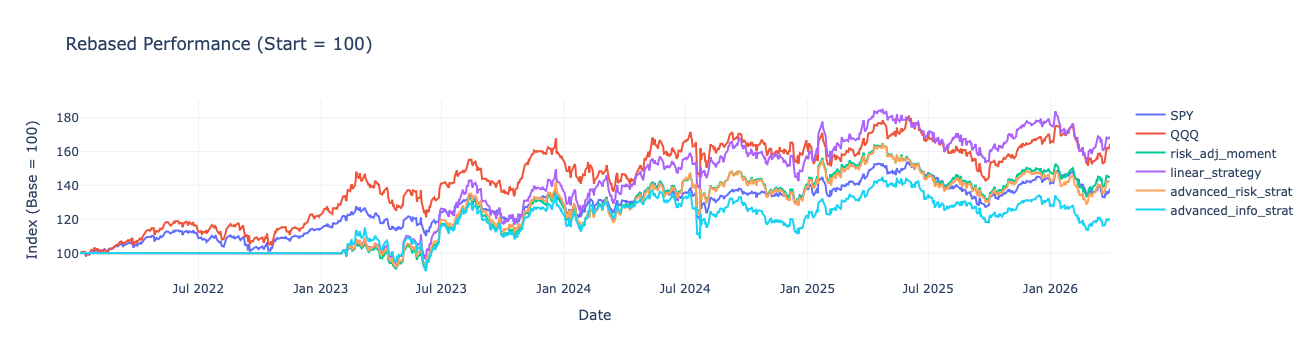

In [32]:
peek_sim_id = 345

df_nav_peek = bootstrap.simulation.build_world_nav(
    peek_sim_id,
    price_tensor[peek_sim_id],
    volume_tensor[peek_sim_id],
    dates_index,
    eng_tickers,
    eng_rebalance_dates,
    SCORER_CONFIGS,
    bench_tickers,
)

evaluation.plot_rebased_performance(df_nav_peek)


In [34]:
bootstrap_metrics.head(10)

,sim_id,scorer,CAGR,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio
0,3,SPY,0.032281,0.309299,0.500934,0.201167,0.160466
1,3,QQQ,0.043082,0.351196,0.572815,0.240896,0.178843
2,3,risk_adj_moment,0.165751,0.928885,1.560364,0.215968,0.767480
3,3,linear_strategy,0.227605,1.108948,1.870847,0.219014,1.039223
4,3,advanced_risk_strat,0.184427,0.962672,1.629666,0.217504,0.847927
5,3,advanced_info_strat,0.156504,0.845104,1.392328,0.204559,0.765080
6,0,SPY,0.169704,1.070249,1.874612,0.250325,0.677935
7,0,QQQ,0.222189,1.101504,1.943728,0.316491,0.702038
8,0,risk_adj_moment,0.151599,0.843346,1.444368,0.369301,0.410503
9,0,linear_strategy,0.160712,0.838802,1.434405,0.386010,0.416340


## 5. Distribution of each metric across worlds, per scorer

In [62]:
bootstrap_metrics_sum=bootstrap_metrics.groupby("scorer").agg(["mean", "std"])
bootstrap_metrics_sum.to_csv('drop_data/bootstrap_metrics_sum.csv')

In [63]:
bootstrap_metrics_sum

sim_id                  CAGR           Sharpe_Ratio  \
                      mean         std      mean       std         mean   
scorer                                                                    
QQQ                  499.5  288.819436  0.106023  0.127339     0.656085   
SPY                  499.5  288.819436  0.096561  0.090987     0.741834   
advanced_info_strat  499.5  288.819436  0.136103  0.131636     0.768701   
advanced_risk_strat  499.5  288.819436  0.170778  0.138257     0.929976   
linear_strategy      499.5  288.819436  0.170447  0.139666     0.916413   
risk_adj_moment      499.5  288.819436  0.170767  0.130640     0.975180   

                              Sortino_Ratio           Max_Drawdown            \
                          std          mean       std         mean       std   
scorer                                                                         
QQQ                  0.618790      1.112152  1.059999     0.313702  0.099476   
SPY                  0.599346      1.248808  1.028680     0.236905  0.075805   
advanced_info_strat  0.589819      1.309619  1.029984     0.281040  0.071403   
advanced_risk_strat  0.589831      1.585075  1.042362     0.262643  0.063968   
linear_strategy      0.590621      1.565909  1.045151     0.272248  0.069101   
risk_adj_moment      0.599044      1.668324  1.064070     0.252633  0.066701   

                    Calmar_Ratio            
                            mean       std  
scorer                                      
QQQ                     0.472637  0.587024  
SPY                     0.539644  0.567958  
advanced_info_strat     0.590462  0.641410  
advanced_risk_strat     0.756486  0.713616  
linear_strategy         0.741157  0.707829  
risk_adj_moment         0.797750  0.717803

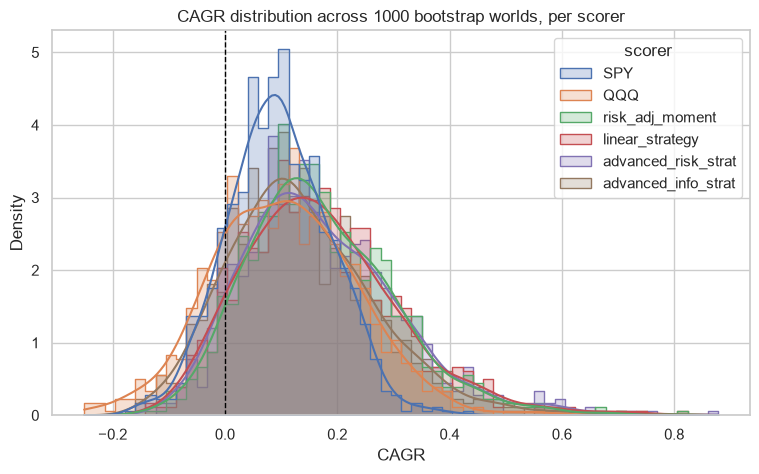

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=bootstrap_metrics, x="CAGR", hue="scorer",
    stat="density", common_norm=False, kde=True,
    element="step", alpha=0.25, ax=ax,
)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_title(f"CAGR distribution across {NUM_SIMULATIONS} bootstrap worlds, per scorer")
plt.show()

In [84]:
# bootstrap_metrics

## 6. Is each scorer significantly different from the benchmarks?

`sim_id` pairs every scorer with SPY/QQQ on the SAME synthetic world, so
this is a paired-samples question, not independent-samples -- an unpaired
test would throw away that pairing and understate power. `src2.bootstrap.significance`
(built on the paired-test helpers in `src2/evaluation/significance_test.py`)
reports, per scorer x benchmark x metric:

- `win_rate` / `ci_2.5`-`ci_97.5`: assumption-free -- fraction of worlds
  the scorer beat the benchmark in, and the empirical 95% CI of the
  per-world difference. This is the number to lead with.
- `p_value` / `significant_at_5pct`: `evaluation.automated_paired_test`
  picks a paired t-test or Wilcoxon signed-rank test per Shapiro
  normality check on the differences, as a formal cross-check.

In [37]:
scorer_names = list(SCORER_CONFIGS.keys())

sig_results = bootstrap.significance.compare_all(
    bootstrap_metrics,
    scorers=scorer_names,
    benches=bench_tickers,
)


In [38]:
sig_results.columns

Index(['scorer', 'bench', 'metric', 'n_sims', 'mean_diff', 'median_diff',
       'win_rate', 'ci_2.5', 'ci_97.5', 'test_name', 'statistic', 'p_value',
       'significant_at_5pct'],
      dtype='str')

In [39]:
sig_results[sig_results["metric"] == "CAGR"][
    ["scorer", "bench", "win_rate", "mean_diff", "ci_2.5", "ci_97.5", "test_name", "p_value", "significant_at_5pct"]
].sort_values(["scorer", "bench"])

,scorer,bench,win_rate,mean_diff,ci_2.5,ci_97.5,test_name,p_value,significant_at_5pct
35,advanced_info_strat,QQQ,0.638,0.030079,-0.107882,0.195701,Wilcoxon Signed-Rank Test,6.482445e-30,True
30,advanced_info_strat,SPY,0.684,0.039541,-0.088803,0.205408,Wilcoxon Signed-Rank Test,4.409187e-47,True
25,advanced_risk_strat,QQQ,0.793,0.064755,-0.073265,0.220698,Wilcoxon Signed-Rank Test,1.915039e-97,True
20,advanced_risk_strat,SPY,0.829,0.074217,-0.055062,0.255414,Wilcoxon Signed-Rank Test,3.010006e-116,True
15,linear_strategy,QQQ,0.793,0.064424,-0.078875,0.220437,Wilcoxon Signed-Rank Test,1.342099e-95,True
10,linear_strategy,SPY,0.824,0.073886,-0.060375,0.264473,Wilcoxon Signed-Rank Test,6.563821e-113,True
5,risk_adj_moment,QQQ,0.804,0.064744,-0.079402,0.221413,Wilcoxon Signed-Rank Test,2.259263e-101,True
0,risk_adj_moment,SPY,0.842,0.074206,-0.047415,0.236936,Wilcoxon Signed-Rank Test,4.149766e-125,True


In [40]:
bootstrap.significance.compare_scorer_vs_benchmark(bootstrap_metrics, 'QQQ', 'SPY', 'CAGR')


{'scorer': 'QQQ',
 'bench': 'SPY',
 'metric': 'CAGR',
 'n_sims': 1000,
 'mean_diff': np.float64(0.009462053988256464),
 'median_diff': np.float64(0.007676627556689075),
 'win_rate': np.float64(0.56),
 'ci_2.5': np.float64(-0.07638290671997067),
 'ci_97.5': np.float64(0.11996935923118476),
 'test_name': 'Wilcoxon Signed-Rank Test',
 'statistic': np.float64(205160.0),
 'p_value': np.float64(7.987998511522557e-07),
 'significant_at_5pct': np.True_}

### 6b. One-sided: did the scorer beat the benchmark? (not just "differ from it")

`compare_scorer_vs_benchmark_one_sided` / `compare_all_one_sided` test
H1: scorer > bench directly (`alternative="greater"`), which is what
"does this scorer actually beat SPY/QQQ" really is -- a one-sided test
has more power for that directional question than the two-sided test in
section 6, at the same significance threshold.

In [42]:
sig_results_one_sided = bootstrap.significance.compare_all_one_sided(
    bootstrap_metrics,
    scorers=scorer_names,
    benches=bench_tickers,
    alternative="greater",
)

sig_results_one_sided[sig_results_one_sided["metric"] == "CAGR"][
    ["scorer", "bench", "win_rate", "mean_diff", "test_name", "p_value", "significant_at_5pct"]
].sort_values(["scorer", "bench"])


,scorer,bench,win_rate,mean_diff,test_name,p_value,significant_at_5pct
35,advanced_info_strat,QQQ,0.638,0.030079,"Wilcoxon Signed-Rank Test (one-sided, greater)",3.241223e-30,True
30,advanced_info_strat,SPY,0.684,0.039541,"Wilcoxon Signed-Rank Test (one-sided, greater)",2.204593e-47,True
25,advanced_risk_strat,QQQ,0.793,0.064755,"Wilcoxon Signed-Rank Test (one-sided, greater)",9.575193e-98,True
20,advanced_risk_strat,SPY,0.829,0.074217,"Wilcoxon Signed-Rank Test (one-sided, greater)",1.505003e-116,True
15,linear_strategy,QQQ,0.793,0.064424,"Wilcoxon Signed-Rank Test (one-sided, greater)",6.710494e-96,True
10,linear_strategy,SPY,0.824,0.073886,"Wilcoxon Signed-Rank Test (one-sided, greater)",3.281910e-113,True
5,risk_adj_moment,QQQ,0.804,0.064744,"Wilcoxon Signed-Rank Test (one-sided, greater)",1.129632e-101,True
0,risk_adj_moment,SPY,0.842,0.074206,"Wilcoxon Signed-Rank Test (one-sided, greater)",2.074883e-125,True


In [43]:
bootstrap.significance.compare_scorer_vs_benchmark(bootstrap_metrics, 'QQQ', 'SPY', 'CAGR')


{'scorer': 'QQQ',
 'bench': 'SPY',
 'metric': 'CAGR',
 'n_sims': 1000,
 'mean_diff': np.float64(0.009462053988256464),
 'median_diff': np.float64(0.007676627556689075),
 'win_rate': np.float64(0.56),
 'ci_2.5': np.float64(-0.07638290671997067),
 'ci_97.5': np.float64(0.11996935923118476),
 'test_name': 'Wilcoxon Signed-Rank Test',
 'statistic': np.float64(205160.0),
 'p_value': np.float64(7.987998511522557e-07),
 'significant_at_5pct': np.True_}

In [45]:
wide = bootstrap_metrics.pivot(index="sim_id", columns="scorer", values='CAGR')
scorer='QQQ'
bench='SPY'
evaluation.automated_paired_test_one_sided(wide[scorer], wide[bench], alternative='greater')


{'test_name': 'Wilcoxon Signed-Rank Test (one-sided, greater)',
 'statistic': np.float64(295340.0),
 'p_value': np.float64(3.9939992557612786e-07),
 'significant_at_5pct': np.True_}

## 7. Conditional performance: does each scorer's edge depend on the market regime?

Sections 6/6b pool all worlds into one win-rate/p-value. That averages away
the more useful question: a mean-reversion scorer that wins in choppy
markets and loses in trending ones could pool to a mediocre-looking
average despite having a real, strong conditional edge. Classify each
world's regime from its benchmark's raw price path (no backtest needed --
see notes/stationary_bootstrap.md section 5 for why R² of a log-price
trend fit, not just net return), then rerun the paired comparison *within*
each regime.

Two passes, since "bull/bear" is only meaningful relative to the spread of
outcomes across all worlds:
1. `classify_world_regime` per sim_id -- cheap (just an OLS fit), plain loop.
2. `label_regimes` buckets by tercile of total_return (direction) and R²
   threshold (trending vs. choppy) across the whole population at once.

In [47]:
REGIME_TICKER = 'SPY'

trend_features = pd.DataFrame([
    bootstrap.data_gen.classify_world_regime(
        sim_id, price_tensor[sim_id], dates_index, eng_tickers,
        regime_ticker=REGIME_TICKER, warmup_days=WARMUP_DAYS,
    )
    for sim_id in range(NUM_SIMULATIONS)
])

world_regimes = bootstrap.data_gen.label_regimes(trend_features)
world_regimes['regime'].value_counts()


regime
choppy        565
bull_trend    416
bear_trend     19
Name: count, dtype: int64

In [48]:
bootstrap_metrics_regime = bootstrap_metrics.merge(
    world_regimes[['sim_id', 'regime', 'total_return', 'r2']], on='sim_id', how='left'
)

conditional_results = pd.concat([
    bootstrap.significance.compare_all(
        bootstrap_metrics_regime[bootstrap_metrics_regime['regime'] == regime],
        scorers=scorer_names,
        benches=bench_tickers,
        metrics=['CAGR'],
    ).assign(regime=regime)
    for regime in world_regimes['regime'].unique()
], ignore_index=True)

conditional_results[
    ['regime', 'scorer', 'bench', 'n_sims', 'win_rate', 'mean_diff', 'p_value', 'significant_at_5pct']
].sort_values(['scorer', 'bench', 'regime'])

,regime,scorer,bench,n_sims,win_rate,mean_diff,p_value,significant_at_5pct
23,bear_trend,advanced_info_strat,QQQ,19,1.000000,0.079975,4.591516e-07,True
15,bull_trend,advanced_info_strat,QQQ,416,0.588942,0.019322,1.376237e-05,True
7,choppy,advanced_info_strat,QQQ,565,0.661947,0.036322,3.869325e-26,True
22,bear_trend,advanced_info_strat,SPY,19,0.736842,0.031942,6.720892e-03,True
14,bull_trend,advanced_info_strat,SPY,416,0.716346,0.052348,2.222008e-27,True
6,choppy,advanced_info_strat,SPY,565,0.658407,0.030367,2.094409e-20,True
21,bear_trend,advanced_risk_strat,QQQ,19,1.000000,0.125357,2.145233e-09,True
13,bull_trend,advanced_risk_strat,QQQ,416,0.769231,0.060557,4.512359e-35,True
5,choppy,advanced_risk_strat,QQQ,565,0.803540,0.065807,5.070354e-61,True
20,bear_trend,advanced_risk_strat,SPY,19,1.000000,0.077324,2.542425e-07,True


In [51]:
scorer_names_check=['risk_adj_moment','QQQ','SPY']

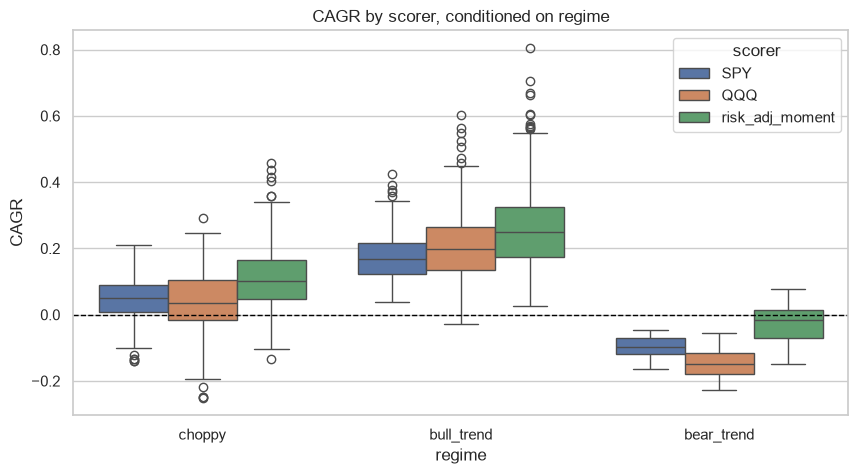

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=bootstrap_metrics_regime[bootstrap_metrics_regime['scorer'].isin(scorer_names_check)],
    x='regime', y='CAGR', hue='scorer', ax=ax,
)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('CAGR by scorer, conditioned on regime')
plt.show()

In [53]:
conditional_results.columns

Index(['scorer', 'bench', 'metric', 'n_sims', 'mean_diff', 'median_diff',
       'win_rate', 'ci_2.5', 'ci_97.5', 'test_name', 'statistic', 'p_value',
       'significant_at_5pct', 'regime'],
      dtype='str')

In [54]:
conditional_results.loc[conditional_results['regime']=='choppy',['scorer','bench','significant_at_5pct','mean_diff','median_diff','win_rate']]

,scorer,bench,significant_at_5pct,mean_diff,median_diff,win_rate
0,risk_adj_moment,SPY,True,0.063862,0.060102,0.823009
1,risk_adj_moment,QQQ,True,0.069817,0.064799,0.840708
2,linear_strategy,SPY,True,0.059882,0.057008,0.792920
3,linear_strategy,QQQ,True,0.065837,0.064152,0.814159
4,advanced_risk_strat,SPY,True,0.059852,0.054321,0.801770
5,advanced_risk_strat,QQQ,True,0.065807,0.063326,0.803540
6,advanced_info_strat,SPY,True,0.030367,0.025079,0.658407
7,advanced_info_strat,QQQ,True,0.036322,0.029110,0.661947


In [55]:
conditional_results.loc[conditional_results['regime']=='bull_trend',['scorer','bench','significant_at_5pct','mean_diff','median_diff','win_rate']]

,scorer,bench,significant_at_5pct,mean_diff,median_diff,win_rate
8,risk_adj_moment,SPY,True,0.088383,0.079738,0.860577
9,risk_adj_moment,QQQ,True,0.055356,0.051959,0.745192
10,linear_strategy,SPY,True,0.093464,0.082381,0.862981
11,linear_strategy,QQQ,True,0.060437,0.059881,0.754808
12,advanced_risk_strat,SPY,True,0.093584,0.085474,0.858173
13,advanced_risk_strat,QQQ,True,0.060557,0.058241,0.769231
14,advanced_info_strat,SPY,True,0.052348,0.047065,0.716346
15,advanced_info_strat,QQQ,True,0.019322,0.013074,0.588942


`world_regimes` already carries `sim_id` alongside `regime` (it flows
straight through from `classify_world_regime`'s dict), so
`world_regimes[world_regimes['regime'] == 'choppy']['sim_id']` works
directly -- `bootstrap.data_gen.sample_sim_ids_per_regime` just wraps that
filter and, by default, picks the most extreme example of each regime
(highest total_return for bull_trend, lowest for bear_trend, lowest r2 for
choppy) rather than a borderline case near a tercile/R² cutoff.

In [56]:
example_sim_ids = bootstrap.data_gen.sample_sim_ids_per_regime(world_regimes,n_per_regime=10)
example_sim_ids


{'bear_trend': [958, 930, 638, 730, 414, 325, 360, 165, 166, 783],
 'bull_trend': [587, 716, 995, 150, 816, 863, 972, 148, 49, 373],
 'choppy': [310, 927, 399, 109, 129, 951, 199, 655, 688, 784]}

regime=choppy  sim_id=129


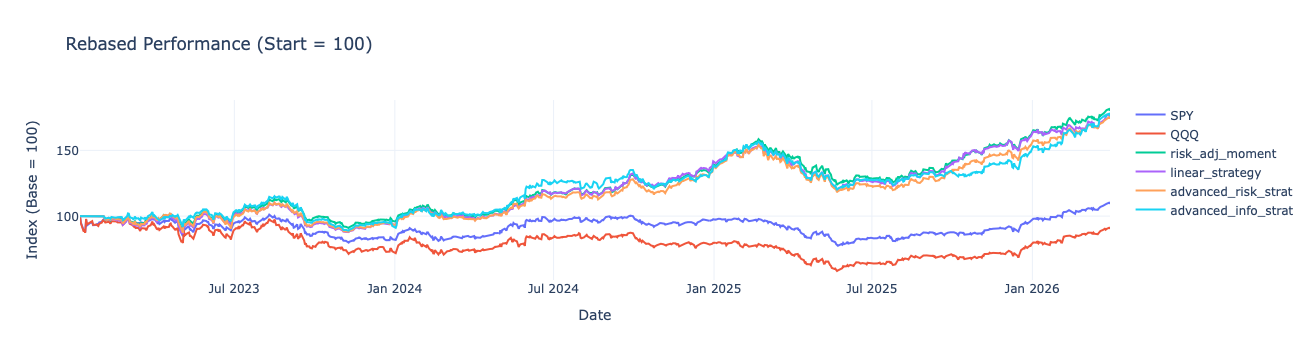

In [57]:
# for regime, sim_ids in example_sim_ids.items():
regime='choppy'
sim_ids=example_sim_ids[regime]
peek_sim_id = sim_ids[4]
df_nav_peek = bootstrap.simulation.build_world_nav(
    peek_sim_id,
    price_tensor[peek_sim_id],
    volume_tensor[peek_sim_id],
    dates_index,
    eng_tickers,
    eng_rebalance_dates,
    SCORER_CONFIGS,
    bench_tickers,
    warmup_days=WARMUP_DAYS
)
print(f"regime={regime}  sim_id={peek_sim_id}")
evaluation.plot_rebased_performance(df_nav_peek)
